In [ ]:
import pandas as pd
import numpy as np
import os
import glob
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = '/content/drive/My Drive/Turning_coarsen_CSV/'  # Update with your actual path
LABELS_PATH = '/content/drive/My Drive/Turning_human_labels.xlsx'

# Load labels file
labels_df = pd.read_excel(LABELS_PATH)

In [ ]:
labels_dict = {
    int(row["Turn ID"]): {
        "PD_or_C": row["PD_or_C"],
        "turning_angle": row["turning_angle"],
        "medication_status": row["On_or_Off_medication"]
    }
    for _, row in labels_df.iterrows()
}

print("Labels loaded successfully!")

Labels loaded successfully!


In [ ]:
# Normalize keypoints function
def normalize_keypoints(keypoints):
    keypoints = keypoints.astype(float)
    x_min, x_max = keypoints[:, 0::2].min(), keypoints[:, 0::2].max()
    y_min, y_max = keypoints[:, 1::2].min(), keypoints[:, 1::2].max()
    keypoints[:, 0::2] = (keypoints[:, 0::2] - x_min) / (x_max - x_min)  # Normalize X
    keypoints[:, 1::2] = (keypoints[:, 1::2] - y_min) / (y_max - y_min)  # Normalize Y
    return keypoints

In [ ]:
# Convert to numpy arrays
data = np.array(data, dtype=object)  # Object dtype to handle variable sequence lengths
labels = np.array(labels)

# Save processed data
np.save('/content/drive/My Drive/gait_keypoints.npy', data)
np.save('/content/drive/My Drive/gait_labels.npy', labels)

print("Preprocessing complete! Data saved.")

Preprocessing complete! Data saved.


In [ ]:
print("Sample Mappings (Turn ID -> Label Info):")
print(list(labels_dict.items())[:5])  # Show first 5 entries

Sample Mappings (Turn ID -> Label Info):
[(0, {'PD_or_C': 'C', 'turning_angle': '90_degrees', 'medication_status': 'Control'}), (2, {'PD_or_C': 'C', 'turning_angle': '90_degrees', 'medication_status': 'Control'}), (4, {'PD_or_C': 'C', 'turning_angle': '90_degrees', 'medication_status': 'Control'}), (5, {'PD_or_C': 'C', 'turning_angle': '90_degrees', 'medication_status': 'Control'}), (7, {'PD_or_C': 'C', 'turning_angle': '90_degrees', 'medication_status': 'Control'})]


In [ ]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

# Check data types
print("\nData types:\n", df.dtypes)

# Check if the number of columns makes sense (should be 2D keypoints)
num_keypoints = df.shape[1] // 2  # Since each keypoint has (x, y)
print(f"\nDetected {num_keypoints} keypoints in the dataset.")

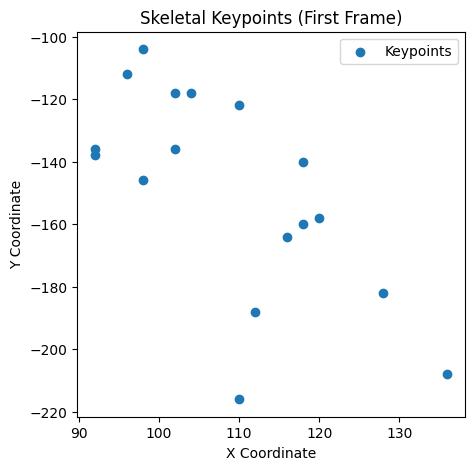

In [ ]:
import matplotlib.pyplot as plt

# Select a frame (first row)
frame = df.iloc[0].values.reshape(-1, 2)  # Reshape into (x, y) pairs

plt.figure(figsize=(5, 5))
plt.scatter(frame[:, 0], -frame[:, 1], marker='o', label="Keypoints")  # Invert Y-axis for proper visualization
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Skeletal Keypoints (First Frame)")
plt.legend()
plt.show()

In [ ]:
import numpy as np

# Normalize keypoints based on min-max scaling
def normalize_keypoints(df):
    min_x, max_x = df.iloc[:, 0::2].min().min(), df.iloc[:, 0::2].max().max()
    min_y, max_y = df.iloc[:, 1::2].min().min(), df.iloc[:, 1::2].max().max()

    df.iloc[:, 0::2] = (df.iloc[:, 0::2] - min_x) / (max_x - min_x)  # Normalize X
    df.iloc[:, 1::2] = (df.iloc[:, 1::2] - min_y) / (max_y - min_y)  # Normalize Y

    return df

df_normalized = normalize_keypoints(df.copy())
print(df_normalized.head())  # Check normalized values

         0         1         2         3         4         5         6   \
0  0.392157  0.565217  0.411765  0.550725  0.490196  0.724638  0.568627   
1  0.411765  0.565217  0.411765  0.536232  0.470588  0.724638  0.568627   
2  0.411765  0.565217  0.411765  0.536232  0.470588  0.724638  0.568627   
3  0.411765  0.565217  0.411765  0.536232  0.470588  0.724638  0.568627   
4  0.411765  0.565217  0.411765  0.536232  0.470588  0.724638  0.568627   

         7         8         9   ...        24        25        26        27  \
0  0.913043  0.372549  0.594203  ...  0.196078  0.463768  0.137255  0.405797   
1  0.898551  0.392157  0.579710  ...  0.196078  0.434783  0.098039  0.405797   
2  0.898551  0.392157  0.579710  ...  0.196078  0.434783  0.098039  0.405797   
3  0.898551  0.392157  0.579710  ...  0.196078  0.434783  0.098039  0.434783   
4  0.898551  0.392157  0.579710  ...  0.196078  0.434783  0.098039  0.405797   

         28       29        30        31        32        33  
0  0.

In [ ]:
# Fill missing values using linear interpolation
df_filled = df_normalized.interpolate(method='linear', axis=0)

# If there are still NaNs (e.g., first or last frame), fill with nearest values
df_filled = df_filled.fillna(method='bfill').fillna(method='ffill')

print("Missing values after filling:\n", df_filled.isnull().sum().sum())

Missing values after filling:
 0


<ipython-input-13-58fbc49a93b6>:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df_filled.fillna(method='bfill').fillna(method='ffill')


In [ ]:
from tqdm import tqdm

dataset_path = "/content/drive/My Drive/Turning_coarsen_CSV/"

print("Checking first 5 patient folders:")
print(os.listdir(dataset_path)[:5])  # Debug

for patient_folder in tqdm(os.listdir(dataset_path), desc="Processing Patients"):
    patient_path = os.path.join(dataset_path, patient_folder)

    if not os.path.isdir(patient_path):
        continue

    input_2d_path = os.path.join(patient_path, "input_2D")

    if not os.path.exists(input_2d_path):
        print(f"input_2D folder missing: {input_2d_path}")
        continue

    keypoints_file = os.path.join(input_2d_path, "keypoints.csv")

    if not os.path.exists(keypoints_file):
        print(f"Missing keypoints.csv: {keypoints_file}")
        continue

    print(f"Found: {keypoints_file}")

print("Debugging complete.")

In [ ]:
dataset_path = "/content/drive/My Drive/Turning_coarsen_CSV/"
output_path = "/content/drive/My Drive/processed_data/"

# Ensure output directory exists
os.makedirs(output_path, exist_ok=True)

def preprocess_keypoints(df):
    """Normalize keypoints and reshape."""
    df = df.astype(float)  # Ensure all values are float

    # Normalize between 0 and 1
    min_val = df.min().min()
    max_val = df.max().max()
    df = (df - min_val) / (max_val - min_val)

    return df

print("Starting batch preprocessing...")

for patient_folder in tqdm(os.listdir(dataset_path), desc="Processing Patients"):
    patient_path = os.path.join(dataset_path, patient_folder)

    if not os.path.isdir(patient_path):
        continue

    input_2d_path = os.path.join(patient_path, "input_2D")
    keypoints_file = os.path.join(input_2d_path, "keypoints.csv")

    if not os.path.exists(keypoints_file):
        continue  # Skip if missing

    # Load CSV
    df = pd.read_csv(keypoints_file, header=None)

    # Preprocess
    processed_df = preprocess_keypoints(df)

    # Save processed file
    save_path = os.path.join(output_path, f"{patient_folder}_processed.csv")
    processed_df.to_csv(save_path, index=False)

print("Batch preprocessing complete. Processed files saved in 'processed_data'.")

Starting batch preprocessing...


Processing Patients: 100%|██████████| 1749/1749 [23:26<00:00,  1.24it/s]

Batch preprocessing complete. Processed files saved in 'processed_data'.


In [ ]:
labels_path = "/content/drive/My Drive/gait_labels.npy"

np.save(labels_path, labels_dict, allow_pickle=True)
print("Labels re-saved successfully!")

Labels re-saved successfully!


In [ ]:
labels_loaded = np.load(labels_path, allow_pickle=True).item()
print("Loaded Labels Type:", type(labels_loaded))
print("First 5 Labels:", list(labels_loaded.items())[:5])

Loaded Labels Type: <class 'dict'>
First 5 Labels: [(0, {'PD_or_C': 'C', 'turning_angle': '90_degrees', 'medication_status': 'Control'}), (2, {'PD_or_C': 'C', 'turning_angle': '90_degrees', 'medication_status': 'Control'}), (4, {'PD_or_C': 'C', 'turning_angle': '90_degrees', 'medication_status': 'Control'}), (5, {'PD_or_C': 'C', 'turning_angle': '90_degrees', 'medication_status': 'Control'}), (7, {'PD_or_C': 'C', 'turning_angle': '90_degrees', 'medication_status': 'Control'})]


In [ ]:
DATASET_PATH = "/content/drive/My Drive/Turning_coarsen_CSV"

# Find all .header.html and .footer.html files
files_to_delete = glob.glob(os.path.join(DATASET_PATH, "*.header.html")) + glob.glob(os.path.join(DATASET_PATH, "*.footer.html"))

# Delete each file
for file in files_to_delete:
    try:
        os.remove(file)
        print(f"Deleted: {file}")
    except Exception as e:
        print(f"Error deleting {file}: {e}")

print("Deletion complete.")

Deletion complete.


In [ ]:
# Paths
DATASET_PATH = "/content/drive/My Drive/Turning_coarsen_CSV"
OUTPUT_PATH = "/content/drive/My Drive/Processed_Gait_Data"
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Load labels
gait_labels = np.load("/content/drive/My Drive/gait_labels.npy", allow_pickle=True).item()

# Process each patient folder
data_entries = []

for patient_folder in tqdm(sorted(os.listdir(DATASET_PATH)), desc="Processing Patients"):
    original_path = os.path.join(DATASET_PATH, patient_folder)

    # Clean up folder name (remove trailing "(1)", "(2)", etc.)
    cleaned_folder = re.sub(r"\s*\(\d+\)$", "", patient_folder)

    # Extract turn ID from folder name
    try:
        turn_id_part = cleaned_folder.split('_n_')[-1]  # Get text after '_n_'
        if not turn_id_part.isdigit():
            print(f"Skipping invalid folder name: {patient_folder}")
            continue
        turn_id = int(turn_id_part)
    except Exception as e:
        print(f"Error extracting turn ID from {patient_folder}: {e}")
        continue

    # Check if turn_id exists in gait_labels
    if turn_id not in gait_labels:
        print(f"Missing label for Turn ID {turn_id}")
        continue

    # Find the actual folder with the correct name
    matching_folders = [f for f in os.listdir(DATASET_PATH) if re.sub(r"\s*\(\d+\)$", "", f) == cleaned_folder]

    if not matching_folders:
        print(f"Could not find matching folder for: {cleaned_folder}")
        continue

    # Use the first matching folder (handles extra copies like `(1)`, `(2)`, etc.)
    correct_folder = matching_folders[0]
    corrected_path = os.path.join(DATASET_PATH, correct_folder)

    # Locate keypoints file
    keypoints_path = os.path.join(corrected_path, "input_2D", "keypoints.csv")

    if not os.path.exists(keypoints_path):
        print(f"Missing keypoints file: {keypoints_path}")
        continue

    # Load keypoints
    df = pd.read_csv(keypoints_path, header=None)
    keypoints = df.to_numpy()

    # Store entry
    data_entries.append({
        "turn_id": turn_id,
        "keypoints": keypoints,
        "label": gait_labels[turn_id]
    })

# Save processed dataset
np.save(os.path.join(OUTPUT_PATH, "processed_gait.npy"), data_entries)
print(f"Processed {len(data_entries)} turns successfully!")


Processing Patients: 100%|██████████| 1749/1749 [01:38<00:00, 17.84it/s]


Processed 1749 turns successfully!


In [ ]:
import numpy as np

data = np.load("/content/drive/My Drive/Processed_Gait_Data/processed_gait.npy", allow_pickle=True)
print(f"Total Entries: {len(data)}")
print("First Entry:", data[0])


Total Entries: 1749
First Entry: {'turn_id': 350, 'keypoints': array([[132., 200., 136., ..., 140., 116., 142.],
       [130., 202., 136., ..., 136., 116., 148.],
       [128., 200., 128., ..., 132., 106., 142.],
       ...,
       [106., 184., 100., ..., 168., 104., 158.],
       [106., 184., 102., ..., 170., 104., 158.],
       [106., 184., 100., ..., 170., 104., 158.]]), 'label': {'PD_or_C': 'C', 'turning_angle': '135_degrees', 'medication_status': 'Control'}}


In [ ]:
unique_labels = {str(entry["label"]) for entry in data}
print("Unique Labels Found:", unique_labels)

Unique Labels Found: {"{'PD_or_C': 'PD', 'turning_angle': '180_degrees', 'medication_status': 'On medication'}", "{'PD_or_C': 'C', 'turning_angle': '360_degrees', 'medication_status': 'Control'}", "{'PD_or_C': 'PD', 'turning_angle': '180_degrees', 'medication_status': 'Off medication'}", "{'PD_or_C': 'C', 'turning_angle': '225_degrees', 'medication_status': 'Control'}", "{'PD_or_C': 'C', 'turning_angle': '180_degrees', 'medication_status': 'Control'}", "{'PD_or_C': 'PD', 'turning_angle': '225_degrees', 'medication_status': 'On medication'}", "{'PD_or_C': 'C', 'turning_angle': '135_degrees', 'medication_status': 'Control'}", "{'PD_or_C': 'C', 'turning_angle': '180_degrees', 'medication_status': 'On medication'}", "{'PD_or_C': 'PD', 'turning_angle': '270_degrees', 'medication_status': 'Off medication'}", "{'PD_or_C': 'PD', 'turning_angle': '90_degrees', 'medication_status': 'On medication'}", "{'PD_or_C': 'PD', 'turning_angle': '135_degrees', 'medication_status': 'Control'}", "{'PD_or_C'

In [ ]:
pd_count = sum(1 for entry in data if entry["label"]["PD_or_C"] == "PD")
c_count = sum(1 for entry in data if entry["label"]["PD_or_C"] == "C")

print(f"PD Turns: {pd_count}, Control Turns: {c_count}")

PD Turns: 963, Control Turns: 786


In [ ]:
import seaborn as sns
from collections import Counter

# Extract relevant data
labels = [entry["label"]["PD_or_C"] for entry in data]
angles = [entry["label"]["turning_angle"] for entry in data]
medications = [entry["label"]["medication_status"] for entry in data]

# Bar Chart: PD vs. Control Turns
plt.figure(figsize=(6, 4))
sns.countplot(x=labels, palette="pastel")
plt.title("Comparison of PD vs. Control Turns")
plt.xlabel("Group")
plt.ylabel("Number of Turns")
plt.show()

In [ ]:
# Pie Chart: Distribution of Turning Angles
angle_counts = Counter(angles)
plt.figure(figsize=(6, 6))
plt.pie(angle_counts.values(), labels=angle_counts.keys(), autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title("Distribution of Turning Angles")
plt.show()

In [ ]:
# Stacked Bar Chart: Medication Status per Turning Angle
med_angle_df = pd.DataFrame({"Turning Angle": angles, "Medication Status": medications})
plt.figure(figsize=(8, 5))
sns.histplot(data=med_angle_df, x="Turning Angle", hue="Medication Status", multiple="stack", palette="pastel")
plt.xticks(rotation=45)
plt.title("Medication Status Breakdown by Turning Angle")
plt.xlabel("Turning Angle")
plt.ylabel("Count")
plt.show()

In [ ]:
df = pd.DataFrame({"Angle": angles, "Label": labels})

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Angle", hue="Label", palette=["red", "blue"])
plt.xlabel("Turning Angle")
plt.ylabel("Count")
plt.title("PD vs. Control Turns for Each Turning Angle")
plt.xticks(rotation=45)
plt.legend(title="Group")
plt.show()

In [ ]:
import numpy as np

def extract_features(keypoints_sequence):
    """
    Extracts gait features from OpenPose-style 2D keypoints.
    :param keypoints_sequence: (frames, 34) array with (x, y) coordinates of 17 joints.
    :return: Feature vector with biomechanical gait features
    """
    keypoints_sequence = np.array(keypoints_sequence).reshape(-1, 17, 2)  # Reshape to (frames, 17 joints, 2)

    # Left & Right Foot Positions
    left_foot = keypoints_sequence[:, 15, :]  # Left Ankle (Index 15)
    right_foot = keypoints_sequence[:, 16, :]  # Right Ankle (Index 16)

    # Step Length (Avg distance between feet over time)
    step_length = np.linalg.norm(left_foot - right_foot, axis=1).mean()

    # Stride Variability (Standard deviation of step length)
    stride_variability = np.std(np.linalg.norm(left_foot - right_foot, axis=1))

    # Turning Speed (Rate of change in head direction)
    head = keypoints_sequence[:, 0, :]  # Nose (Index 0)
    orientation_changes = np.diff(np.arctan2(head[:, 1], head[:, 0]))  # Change in head angle
    turning_speed = np.mean(np.abs(orientation_changes))

    # Balance Sway (Standard deviation of center of mass)
    center_of_mass = (left_foot + right_foot) / 2
    sway_x, sway_y = np.std(center_of_mass, axis=0)  # Sway along X and Y

    # Step Duration (Number of frames where foot displacement occurs)
    foot_movement = np.linalg.norm(np.diff(left_foot, axis=0), axis=1)
    step_duration = (foot_movement > 0.1).sum()  # Count frames where movement > threshold

    # Acceleration Features (Jerk Detection)
    velocity = np.diff(center_of_mass, axis=0)
    acceleration = np.diff(velocity, axis=0)
    jerk = np.mean(np.abs(acceleration))  # Jerk = sudden acceleration changes

    # Hip & Knee Movement (Symmetry Measure)
    left_hip = keypoints_sequence[:, 11, :]
    right_hip = keypoints_sequence[:, 12, :]
    left_knee = keypoints_sequence[:, 13, :]
    right_knee = keypoints_sequence[:, 14, :]

    hip_symmetry = np.mean(np.abs(left_hip - right_hip))
    knee_symmetry = np.mean(np.abs(left_knee - right_knee))

    return [
        step_length, stride_variability, turning_speed,
        sway_x, sway_y, step_duration, jerk, hip_symmetry, knee_symmetry
    ]


In [ ]:
import numpy as np

# Load processed gait data
data = np.load("/content/drive/My Drive/Processed_Gait_Data/processed_gait.npy", allow_pickle=True)

# Extract features for all turns
feature_list = []
labels = []

for entry in data:
    keypoints = entry["keypoints"]  # Extract keypoints
    label = entry["label"]["PD_or_C"]  # Extract label ("PD" or "C")

    # Compute features
    features = extract_features(keypoints)

    # Store results
    feature_list.append(features)
    labels.append(1 if label == "PD" else 0)  # Convert labels to 0 (C) and 1 (PD)

# Convert to NumPy array
X = np.array(feature_list)
y = np.array(labels)

print(f"Feature Matrix Shape: {X.shape}")  # Should be (1749, 9)
print(f"Labels Shape: {y.shape}")  # Should be (1749,)


Feature Matrix Shape: (1749, 9)
Labels Shape: (1749,)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Normalize and reshape features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))  # Reshape for LSTM

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

'\n# Define the improved LSTM model\nmodel = keras.Sequential([\n    keras.layers.LSTM(128, return_sequences=True, \n                      input_shape=(1, X_scaled.shape[2]), \n                      kernel_regularizer=keras.regularizers.l2(0.001)),  # L2 Regularization\n    keras.layers.Dropout(0.5),  # More dropout to reduce overfitting\n    keras.layers.LSTM(64, return_sequences=False, kernel_regularizer=keras.regularizers.l2(0.001)),\n    keras.layers.Dropout(0.5),\n    keras.layers.Dense(32, activation="relu"),\n    keras.layers.Dense(1, activation="sigmoid")  # Binary classification\n])\n\n# Compile with lower learning rate\noptimizer = keras.optimizers.Adam(learning_rate=0.0005)  # Reduce learning rate\nmodel.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])\n\n# Train model with larger batch size\nmodel.fit(X_train, y_train, epochs=75, batch_size=64, validation_data=(X_test, y_test))\n\n# Evaluate model\nloss, accuracy = model.evaluate(X_test, y_test

In [ ]:
# Reshape keypoints for CNN-LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], -1)  # (samples, frames, 34)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Conv1D, LSTM, Dense, Dropout, Flatten, Input

# Define Model
inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))  # (frames, 34 features)

# 🔹 CNN Feature Extraction
x = Conv1D(filters=64, kernel_size=3, activation="relu", padding="same")(inputs)
x = Conv1D(filters=128, kernel_size=3, activation="relu", padding="same")(x)
x = Dropout(0.3)(x)

# 🔹 LSTM for Sequence Learning
x = LSTM(64, return_sequences=True)(x)
x = LSTM(32, return_sequences=False)(x)
x = Dropout(0.3)(x)

# 🔹 Fully Connected Layers
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation="sigmoid")(x)  # Binary classification

# Compile model
model = keras.Model(inputs=inputs, outputs=outputs)
optimizer = keras.optimizers.Adam(learning_rate=0.0003)
model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Track validation loss
    patience=10,         # Stop after 10 epochs of no improvement
    restore_best_weights=True  # Restore best model weights
)

# Train model
history = model.fit(X_train, y_train, epochs=75, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f" Accuracy: {accuracy * 100:.2f}%")

Epoch 1/75
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.5167 - loss: 0.6930 - val_accuracy: 0.5600 - val_loss: 0.6917
Epoch 2/75
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5760 - loss: 0.6911 - val_accuracy: 0.5600 - val_loss: 0.6900
Epoch 3/75
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5500 - loss: 0.6905 - val_accuracy: 0.5600 - val_loss: 0.6883
Epoch 4/75
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5506 - loss: 0.6891 - val_accuracy: 0.5600 - val_loss: 0.6851
Epoch 5/75
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5499 - loss: 0.6866 - val_accuracy: 0.5600 - val_loss: 0.6794
Epoch 6/75
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5338 - loss: 0.6847 - val_accuracy: 0.5600 - val_loss: 0.6693
Epoch 7/75
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5576 - loss: 0.6721 - val_accuracy: 0.5600 - val_loss: 0.6568
Epoch 8/75
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5659 - loss: 0.6657 - val_accuracy: 0.6486 - v